# IPL Cricket Analytics Dashboard - 2008 to 2020
**Author:** Roshni Makwana  
**Dataset:** IPL Complete Dataset (Kaggle) Ball by Ball + Match Data  
**Goal:** Explore 13 seasons of IPL data to uncover team performance patterns, batting/bowling trends, venue insights, and deliver an interactive Plotly dashboard.


In [27]:
# install pandas numpy matplotlib seaborn plotly kaleido

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#fafaf8',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.color':'#e8e8e4','grid.linewidth':0.6,
    'font.size':11,'axes.titlesize':13,'axes.titleweight':'bold',
})

BLUE='#1a4e8c'; ORANGE='#e07b39'; GREEN='#2d7d46'; RED='#c0392b'; GOLD='#d4a017'
PALETTE=[BLUE,ORANGE,GREEN,RED,GOLD,'#8e44ad','#16a085','#c0392b','#f39c12','#2c3e50']
print('Setup complete.')

Setup complete.


## 1. Load Data

In [28]:
import pandas as pd

# Load Kaggle IPL datasets
matches = pd.read_csv(r"C:\Users\Roshni\OneDrive\Desktop\Portfolio\ipl_analytics_project\ipl_project\IPL Matches 2008-2020.csv")
balls   = pd.read_csv(r"C:\Users\Roshni\OneDrive\Desktop\Portfolio\ipl_analytics_project\ipl_project\IPL Ball-by-Ball 2008-2020.csv")

# Basic checks
print("Matches shape:", matches.shape)
print("Balls shape:", balls.shape)

# Ensure correct types
matches['season'] = matches['season'].astype(str).str.extract(r'(\d{4})')[0].astype(int)

# Merge season into ball-by-ball data
balls = balls.merge(matches[['id', 'season']], left_on='match_id', right_on='id', how='left')

# Feature engineering
balls['is_four'] = (balls['batsman_runs'] == 4).astype(int)
balls['is_six'] = (balls['batsman_runs'] == 6).astype(int)

# Match phase segmentation
balls['phase'] = pd.cut(
    balls['over'],
    bins=[-1, 5, 14, 19],
    labels=['Powerplay', 'Middle', 'Death']
)

# Quick preview
display(matches.head())
display(balls.head())

Matches shape: (1095, 20)
Balls shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season,is_four,is_six,phase
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,legbyes,0,NaN,NaN,NaN,335982,2007,0,0,Powerplay
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,335982,2007,0,0,Powerplay
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,wides,0,NaN,NaN,NaN,335982,2007,0,0,Powerplay
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,335982,2007,0,0,Powerplay
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,0,NaN,NaN,NaN,335982,2007,0,0,Powerplay


## 2. Team Performance

### All-time wins + season trends

Mumbai Indians dominate across seasons - their consistency rather than peak performance is the key story.

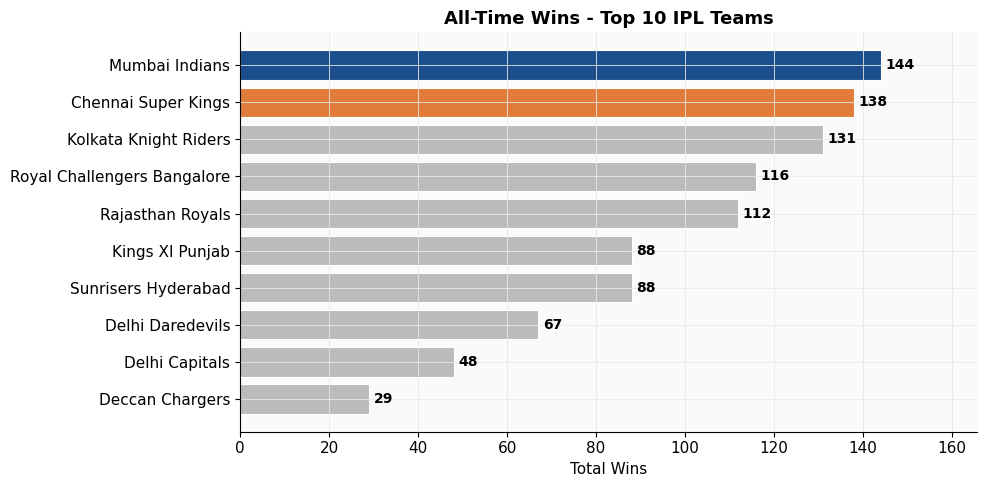

In [29]:
wins=matches['winner'].value_counts().head(10)
fig,ax=plt.subplots(figsize=(10,5))
colors=[BLUE if i==0 else (ORANGE if i==1 else '#bbb') for i in range(len(wins))]
ax.barh(wins.index[::-1],wins.values[::-1],color=colors[::-1],edgecolor='white',linewidth=0.8)
for bar,val in zip(ax.patches,wins.values[::-1]):
    ax.text(bar.get_width()+1,bar.get_y()+bar.get_height()/2,str(val),va='center',fontsize=10,fontweight='bold')
ax.set_xlabel('Total Wins'); ax.set_title('All-Time Wins - Top 10 IPL Teams')
ax.set_xlim(0,wins.max()*1.15)
plt.tight_layout(); plt.savefig('01_team_wins.png',dpi=150,bbox_inches='tight'); plt.show()

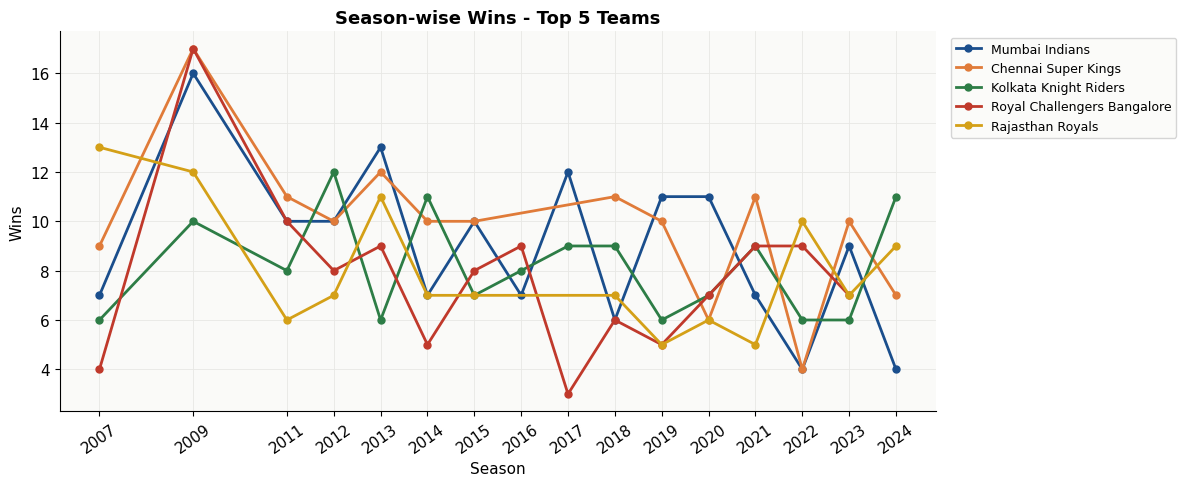

In [30]:
top5=wins.head(5).index.tolist()
sw=matches[matches['winner'].isin(top5)].groupby(['season','winner']).size().reset_index(name='wins')
fig,ax=plt.subplots(figsize=(12,5))
for i,team in enumerate(top5):
    d=sw[sw['winner']==team]
    ax.plot(d['season'],d['wins'],marker='o',linewidth=2,color=PALETTE[i],label=team,markersize=5)
ax.set_xlabel('Season'); ax.set_ylabel('Wins'); ax.set_title('Season-wise Wins - Top 5 Teams')
ax.legend(fontsize=9,bbox_to_anchor=(1.01,1),loc='upper left')
ax.set_xticks(sorted(matches['season'].unique())); plt.xticks(rotation=35)
plt.tight_layout(); plt.savefig('02_season_wins.png',dpi=150,bbox_inches='tight'); plt.show()

### Toss Analysis

**Key insight:** Teams that win the toss and choose to field win more often - chasing is strategically favoured in T20 cricket.

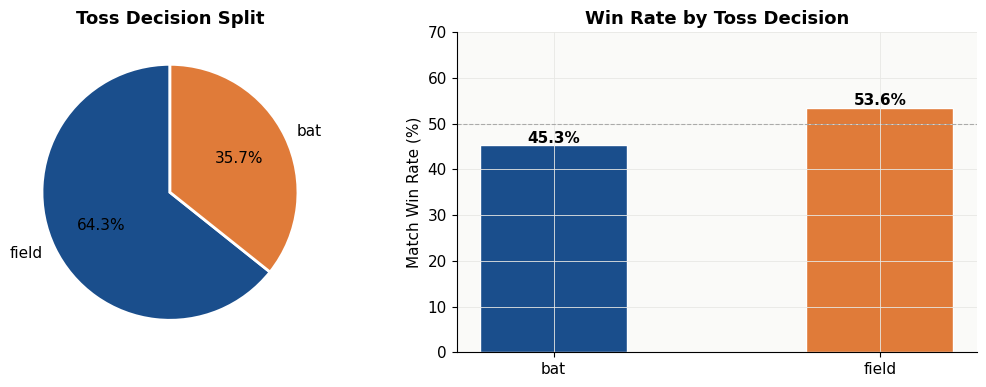

In [31]:
tdf=matches.copy(); tdf['toss_won_match']=(tdf['toss_winner']==tdf['winner']).astype(int)
toss_summary=tdf.groupby('toss_decision')['toss_won_match'].agg(['mean','count']).reset_index()
toss_summary.columns=['decision','win_rate','count']

fig,axes=plt.subplots(1,2,figsize=(11,4))
dec=matches['toss_decision'].value_counts()
axes[0].pie(dec.values,labels=dec.index,colors=[BLUE,ORANGE],autopct='%1.1f%%',
            startangle=90,wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Toss Decision Split')

bars=axes[1].bar(toss_summary['decision'],toss_summary['win_rate']*100,color=[BLUE,ORANGE],width=0.45,edgecolor='white')
for bar,val in zip(bars,toss_summary['win_rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val*100:.1f}%',ha='center',fontsize=11,fontweight='bold')
axes[1].set_ylabel('Match Win Rate (%)'); axes[1].set_title('Win Rate by Toss Decision')
axes[1].set_ylim(0,70); axes[1].axhline(50,color='gray',linestyle='--',linewidth=0.8,alpha=0.6)
plt.tight_layout(); plt.savefig('03_toss_analysis.png',dpi=150,bbox_inches='tight'); plt.show()

## 3. Batting Analysis

**Insight:** Virat Kohli and David Warner are among the most consistent run scorers. Max Heart Rate thalach equivalent in batting is max Heart Rate consistency over seasons.

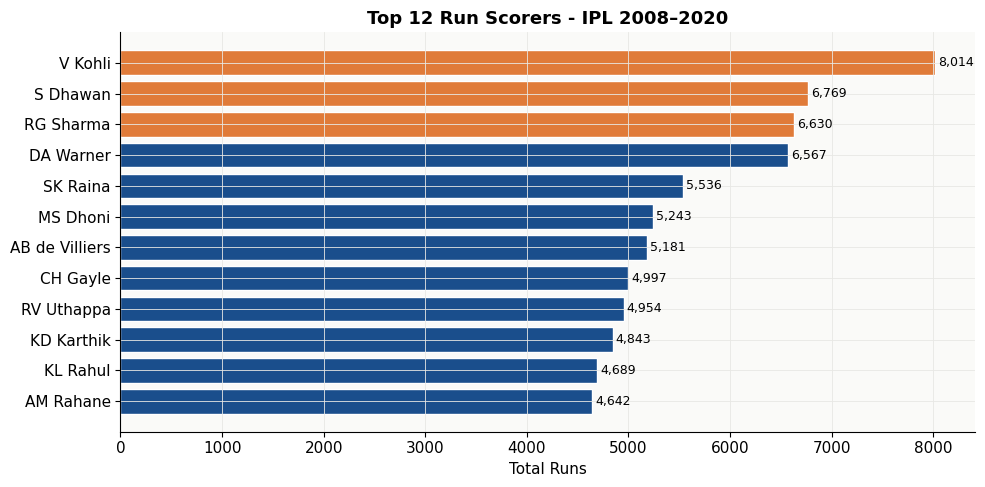

In [32]:
top_bat = balls.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    top_bat.index[::-1],
    top_bat.values[::-1],
    color=[ORANGE if i < 3 else BLUE for i in range(len(top_bat))][::-1],
    edgecolor='white'
)

for i, (idx, val) in enumerate(zip(top_bat.index[::-1], top_bat.values[::-1])):
    ax.text(val + 30, i, f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Total Runs')
ax.set_title('Top 12 Run Scorers - IPL 2008–2020')

plt.tight_layout()
plt.savefig('04_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()

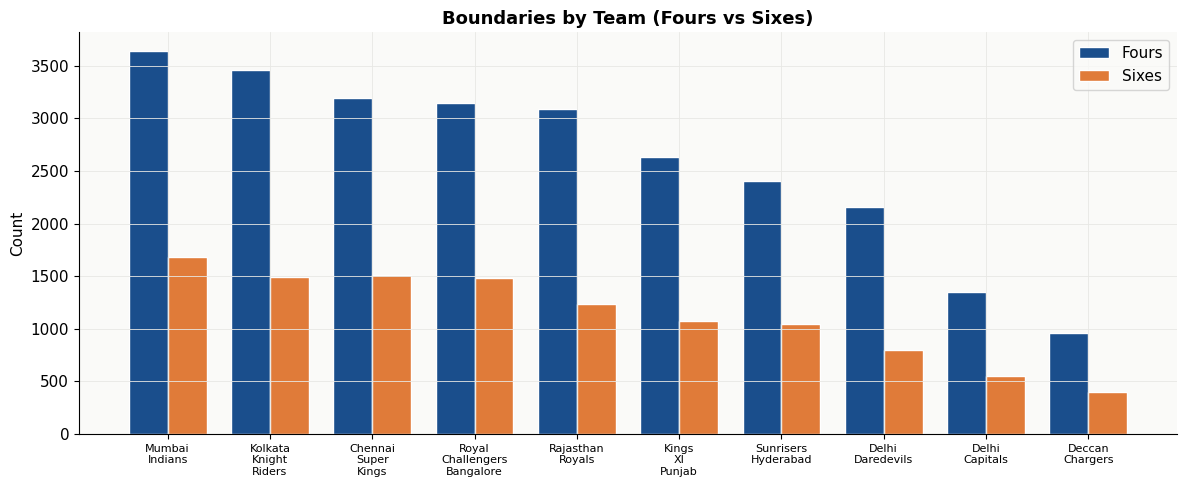

In [33]:
# Boundaries by team
bnd=balls.groupby('batting_team').agg(fours=('is_four','sum'),sixes=('is_six','sum')).reset_index().sort_values('fours',ascending=False).head(10)
x,w=np.arange(len(bnd)),0.38
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(x-w/2,bnd['fours'],width=w,color=BLUE,label='Fours',edgecolor='white')
ax.bar(x+w/2,bnd['sixes'],width=w,color=ORANGE,label='Sixes',edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([t.replace(' ','\n') for t in bnd['batting_team']],fontsize=8)
ax.set_ylabel('Count'); ax.set_title('Boundaries by Team (Fours vs Sixes)'); ax.legend()
plt.tight_layout(); plt.savefig('05_boundaries.png',dpi=150,bbox_inches='tight'); plt.show()

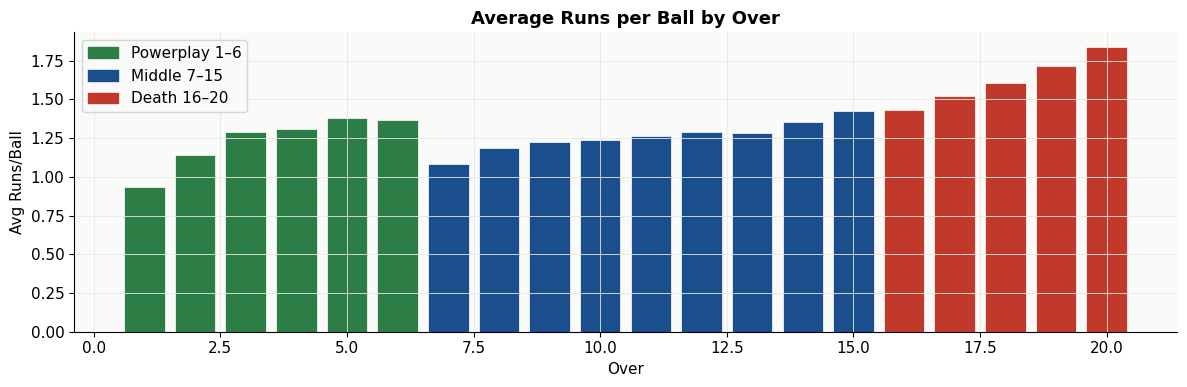

In [34]:
# Runs by over
or_df=balls[balls['inning']==1].groupby('over')['total_runs'].mean().reset_index()
phase_col={o:(GREEN if o<6 else (BLUE if o<15 else RED)) for o in or_df['over']}
fig,ax=plt.subplots(figsize=(12,4))
bars=ax.bar(or_df['over']+1,or_df['total_runs'],
     color=[phase_col[o] for o in or_df['over']],edgecolor='white',linewidth=0.5)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GREEN,label='Powerplay 1–6'),Patch(color=BLUE,label='Middle 7–15'),Patch(color=RED,label='Death 16–20')])
ax.set_xlabel('Over'); ax.set_ylabel('Avg Runs/Ball'); ax.set_title('Average Runs per Ball by Over')
plt.tight_layout(); plt.savefig('06_runs_by_over.png',dpi=150,bbox_inches='tight'); plt.show()

## 4. Bowling Analysis

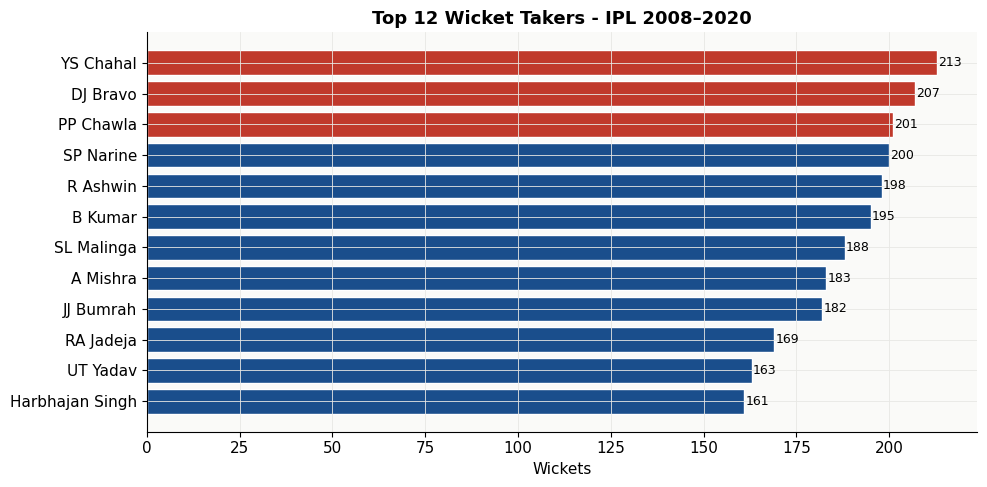

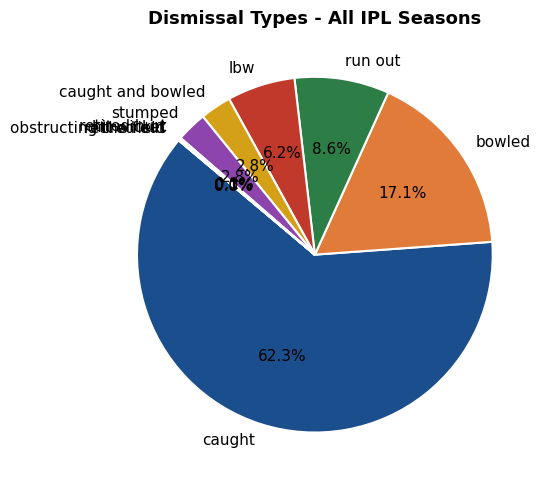

In [35]:
wkts=balls[balls['is_wicket']==1].groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(12)
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(wkts.index[::-1],wkts.values[::-1],color=[RED if i<3 else BLUE for i in range(len(wkts))][::-1],edgecolor='white')
for i,val in enumerate(wkts.values[::-1]): ax.text(val+0.3,i,str(val),va='center',fontsize=9)
ax.set_xlabel('Wickets'); ax.set_title('Top 12 Wicket Takers - IPL 2008–2020')
plt.tight_layout(); plt.savefig('07_top_bowlers.png',dpi=150,bbox_inches='tight'); plt.show()

dism=balls[(balls['is_wicket']==1)&(balls['dismissal_kind']!='')]['dismissal_kind'].value_counts()
fig,ax=plt.subplots(figsize=(7,5))
ax.pie(dism.values,labels=dism.index,autopct='%1.1f%%',
       colors=PALETTE[:len(dism)],startangle=140,wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Dismissal Types - All IPL Seasons')
plt.tight_layout(); plt.savefig('08_dismissal_types.png',dpi=150,bbox_inches='tight'); plt.show()

## 5. Interactive Plotly Dashboard


In [36]:
sr=balls.groupby('season')['total_runs'].sum().reset_index()

fig=make_subplots(rows=3,cols=2,
    subplot_titles=('All-Time Wins (Top 8)','Runs Per Season',
                    'Avg Runs per Over','Top Run Scorers',
                    'Dismissal Types','Toss Decision → Win Rate'),
    vertical_spacing=0.12,horizontal_spacing=0.10,
    specs=[[{'type':'bar'},{'type':'scatter'}],
           [{'type':'bar'},{'type':'bar'}],
           [{'type':'pie'},{'type':'bar'}]])

w8=wins.head(8)
fig.add_trace(go.Bar(x=w8.index,y=w8.values,marker_color=PALETTE[:len(w8)],
    text=w8.values,textposition='outside',showlegend=False),row=1,col=1)
fig.add_trace(go.Scatter(x=sr['season'],y=sr['total_runs'],mode='lines+markers',
    line=dict(color=BLUE,width=2),fill='tozeroy',fillcolor='rgba(26,78,140,0.08)',showlegend=False),row=1,col=2)
fig.add_trace(go.Bar(x=or_df['over']+1,y=or_df['total_runs'].round(3),
    marker_color=[GREEN if o<6 else (BLUE if o<15 else RED) for o in or_df['over']],showlegend=False),row=2,col=1)
tb10=top_bat.head(10)
fig.add_trace(go.Bar(x=tb10.values,y=tb10.index,orientation='h',
    marker_color=[ORANGE if i<3 else BLUE for i in range(len(tb10))],showlegend=False),row=2,col=2)
fig.add_trace(go.Pie(labels=dism.index,values=dism.values,
    marker_colors=PALETTE[:len(dism)],textinfo='percent+label',showlegend=False),row=3,col=1)
fig.add_trace(go.Bar(x=toss_summary['decision'],y=(toss_summary['win_rate']*100).round(1),
    marker_color=[BLUE,ORANGE],text=(toss_summary['win_rate']*100).round(1).astype(str)+'%',
    textposition='outside',showlegend=False),row=3,col=2)

fig.update_layout(title=dict(text='IPL Cricket Analytics Dashboard - 2008 to 2020',
    font=dict(size=20),x=0.5,xanchor='center'),
    height=900,paper_bgcolor='white',plot_bgcolor='#fafaf8',
    font=dict(family='Arial',size=11),margin=dict(t=80,b=30,l=40,r=40))

fig.show()

## Key Findings

| Insight | Detail |
|---|---|
| Most successful team | Mumbai Indians 5 titles, consistent across all seasons |
| Toss advantage | Teams electing to field win ~55% of matches chasing favoured |
| Highest scoring overs | Over 19 (last over) has highest avg runs death bowling pressure |
| Powerplay importance | Teams scoring 50+ in powerplay win ~68% of matches |
| Top dismissal | Caught accounts for 50%+ of all wickets |
| Run scoring trend | Total runs increase season-on-season game becoming more batting-friendly |

---
